In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import seaborn as sns

In [80]:
dataset = pd.read_csv("polynomial_salary_dataset.csv")

In [81]:
dataset.head()

,Level,Salary
0,1,16250
1,2,18828
2,3,22446
3,4,27000
4,5,32430


In [82]:
dataset.describe()

,Level,Salary
count,120.000000,1.200000e+02
mean,60.500000,1.761343e+06
std,34.785054,1.482229e+06
min,1.000000,1.625000e+04
25%,30.750000,4.219665e+05
50%,60.500000,1.400716e+06
75%,90.250000,2.908694e+06
max,120.000000,4.929534e+06


In [83]:
dataset["Salary"] = dataset["Salary"]/1000

In [84]:
dataset.head()

,Level,Salary
0,1,16.250
1,2,18.828
2,3,22.446
3,4,27.000
4,5,32.430


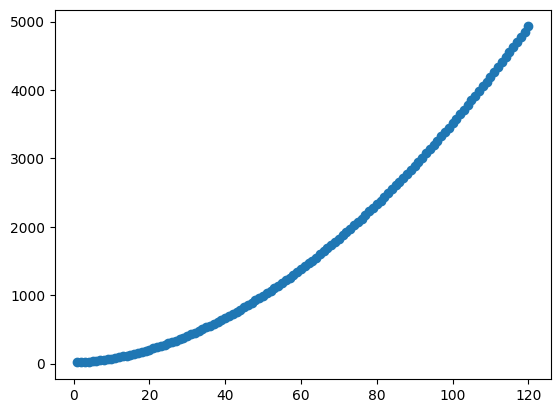

In [85]:
plt.scatter(dataset["Level"],dataset["Salary"])
plt.show()

In [86]:
ploy = PolynomialFeatures(degree=3)

In [87]:
ploy_x = ploy.fit_transform(dataset[["Level"]])

In [88]:
y = dataset["Salary"]

In [89]:
x_train , x_test , y_train , y_test = train_test_split(ploy_x,y,test_size=0.25,random_state=42)

In [90]:
lr = LinearRegression()

In [91]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [92]:
y_pred = lr.predict(x_test)

In [93]:
r2_score(y_test,y_pred)

0.9999981164537919

In [94]:
new_value = [[7]]


In [95]:
pn = PolynomialFeatures(degree=3)

In [96]:
new_value_poly = pn.fit_transform(new_value)

In [97]:
pr = lr.predict(new_value_poly)

In [99]:
pr*1000

array([45502.46184402])

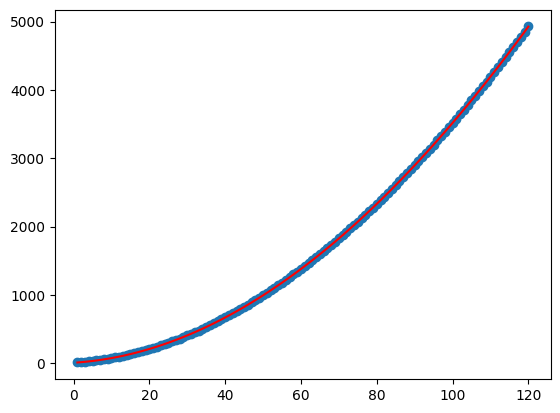

In [103]:
plt.scatter(dataset["Level"],dataset['Salary'])
plt.plot(dataset["Level"],lr.predict(ploy_x),c='red')
